# Análise exploratória dos datasets do Termo Solver

Explora os arquivos `dataset_{palavra_inicial}.csv` gerados pela opção
"Gerar dataset de partidas" do menu em `play.py`. Cada arquivo contém o
resultado de uma simulação completa (todas as palavras do dicionário
como resposta) usando uma palavra inicial fixa.

O menu no final deste notebook permite:
- **Analisar** um único dataset (taxa de vitória, distribuição de
  tentativas, segundas tentativas mais comuns).
- **Comparar** dois ou mais datasets lado a lado, para descobrir qual
  palavra inicial performa melhor em média.

Datasets de amostra (pequenos, gerados com um dicionário reduzido só
para teste) já vêm junto com este notebook -- troque por datasets reais,
gerados com o dicionário completo, para uma análise que valha a pena.

In [2]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

## Carregamento de dados

In [3]:
DATA_DIR = Path("../data")


def listar_datasets() -> list[Path]:
    """
    Lista todos os arquivos dataset_*.csv disponíveis em DATA_DIR.

    Returns
    -------
    list[Path]
        Caminhos dos datasets encontrados, ordenados por nome.
    """
    return sorted(DATA_DIR.glob("dataset_*.csv"))


def nome_dataset(caminho: Path) -> str:
    """Extrai o nome curto (a palavra inicial) a partir do caminho do arquivo."""
    return caminho.stem.replace("dataset_", "")


def carregar_dataset(caminho: Path) -> pd.DataFrame:
    """
    Carrega um dataset de partidas simuladas.

    A coluna "Chutes" é salva no CSV como texto (ex.:
    "('serao', 'termo')") porque é uma tupla Python; aqui ela é
    convertida de volta para uma tupla de verdade com `ast.literal_eval`,
    e uma coluna extra com a segunda tentativa de cada partida é
    derivada para facilitar a análise de quais palavras o algoritmo
    tende a escolher depois da abertura fixa.

    Parameters
    ----------
    caminho : Path
        Caminho do arquivo CSV a carregar.

    Returns
    -------
    pd.DataFrame
    """
    df = pd.read_csv(caminho)
    df["Chutes"] = df["Chutes"].apply(ast.literal_eval)
    df["segunda_tentativa"] = df["Chutes"].apply(lambda c: c[1] if len(c) > 1 else None)
    return df

## Análise de um único dataset

In [4]:
def resumo_dataset(nome: str, df: pd.DataFrame) -> None:
    """
    Imprime um resumo textual do dataset: taxa de vitória, tentativas
    médias entre as vitórias, fração resolvida em até 4 tentativas e as
    segundas tentativas mais comuns.

    Parameters
    ----------
    nome : str
        Nome do dataset (palavra inicial), usado só para o cabeçalho.

    df : pd.DataFrame
        Dataset já carregado por `carregar_dataset`.
    """
    total = len(df)
    taxa_vitoria = df["Vitoria"].mean() if total else 0
    media_tentativas = df.loc[df["Vitoria"], "N_de_tentativas"].mean()
    resolvidas_ate_4 = (df.loc[df["Vitoria"], "N_de_tentativas"] <= 4).mean()

    print(f"=== {nome} ===")
    print(f"Partidas: {total}")
    print(f"Palavra inicial: {df["palavra_inicial"].iloc[0]}")
    print(f"Taxa de vitória: {taxa_vitoria:.1%}")
    print(f"Tentativas médias (vitórias): {media_tentativas:.2f}")
    print(f"Resolvidas em até 4 tentativas: {resolvidas_ate_4:.1%}")
    print()
    print("Segundas tentativas mais comuns:")
    print(df["segunda_tentativa"].value_counts().head(5))


def plotar_distribuicao(nome: str, df: pd.DataFrame) -> None:
    """Plota a distribuição do número de tentativas, separando vitórias e derrotas."""
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.countplot(data=df, x="N_de_tentativas", hue="Vitoria", ax=ax)
    ax.set_title(f"Distribuição de tentativas -- {nome}")
    ax.set_xlabel("Número de tentativas")
    ax.set_ylabel("Partidas")
    plt.tight_layout()
    plt.show()


def analisar_dataset(nome: str) -> None:
    """
    Executa a análise exploratória de um único dataset: carrega o
    arquivo correspondente a `nome`, imprime o resumo e plota a
    distribuição de tentativas.

    Parameters
    ----------
    nome : str
        Palavra inicial que identifica o dataset
        ("dataset_{nome}.csv").
    """
    caminho = DATA_DIR / f"dataset_{nome}.csv"
    if not caminho.exists():
        print(f"Dataset '{nome}' não encontrado.")
        return
    df = carregar_dataset(caminho)
    resumo_dataset(nome, df)
    plotar_distribuicao(nome, df)

## Comparação entre datasets

In [5]:
def comparar_datasets(nomes: list[str]) -> None:
    """
    Compara múltiplos datasets lado a lado: uma tabela com taxa de
    vitória e tentativas médias/medianas por palavra inicial, um
    gráfico de barras da taxa de vitória e um boxplot da distribuição
    completa de tentativas por dataset.

    Parameters
    ----------
    nomes : list[str]
        Palavras iniciais dos datasets a comparar (pelo menos 2).
    """
    resumos = []
    dfs = {}
    for nome in nomes:
        caminho = DATA_DIR / f"dataset_{nome}.csv"
        if not caminho.exists():
            print(f"Dataset '{nome}' não encontrado -- ignorado.")
            continue
        df = carregar_dataset(caminho)
        dfs[nome] = df
        resumos.append({
            "palavra_inicial": nome,
            "partidas": len(df),
            "taxa_vitoria": df["Vitoria"].mean(),
            "tentativas_media": df.loc[df["Vitoria"], "N_de_tentativas"].mean(),
            "tentativas_mediana": df.loc[df["Vitoria"], "N_de_tentativas"].median(),
        })

    if len(resumos) < 2:
        print("Selecione pelo menos 2 datasets válidos para comparar.")
        return

    tabela = pd.DataFrame(resumos).sort_values("tentativas_media").reset_index(drop=True)
    display(tabela)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.barplot(data=tabela, x="palavra_inicial", y="taxa_vitoria", ax=axes[0])
    axes[0].set_title("Taxa de vitória por palavra inicial")
    axes[0].set_ylabel("Taxa de vitória")
    axes[0].set_ylim(0, 1)

    combinado = pd.concat([d.assign(palavra_inicial=n) for n, d in dfs.items()])
    sns.boxplot(data=combinado, x="palavra_inicial", y="N_de_tentativas", ax=axes[1])
    axes[1].set_title("Distribuição de tentativas por palavra inicial")
    axes[1].set_xlabel("Palavra inicial")

    plt.tight_layout()
    plt.show()

## Menu interativo

Rode a célula abaixo e use o menu para navegar entre os datasets
disponíveis em `DATA_DIR`. Gerou um dataset novo depois de abrir este
notebook? Use a opção **r** para recarregar a lista sem precisar
reiniciar o kernel.

In [6]:
def menu() -> None:
    """
    Menu interativo: lista os datasets disponíveis em DATA_DIR e
    permite analisar um único dataset (`analisar_dataset`) ou comparar
    vários (`comparar_datasets`), recarregando a lista sob demanda.
    """
    while True:
        datasets = listar_datasets()
        nomes = [nome_dataset(p) for p in datasets]

        print("\n=== Análise exploratória -- Termo Solver ===")
        if not nomes:
            print(f"Nenhum dataset encontrado em {DATA_DIR.resolve()}.")
            print("Gere datasets com a opção 4 do menu em play.py antes de continuar.")
            return

        for i, nome in enumerate(nomes, start=1):
            print(f"{i}. {nome}")
        print("\na. Analisar um dataset")
        print("c. Comparar vários datasets")
        print("r. Recarregar lista de datasets")
        print("s. Sair")

        escolha = input("Escolha uma opção: ").strip().lower()

        if escolha == "a":
            idx = input("Número do dataset a analisar: ").strip()
            if idx.isdigit() and 1 <= int(idx) <= len(nomes):
                analisar_dataset(nomes[int(idx) - 1])
            else:
                print("Opção inválida.")
        elif escolha == "c":
            idxs = input("Números dos datasets a comparar, separados por vírgula: ").strip()
            selecionados = []
            for parte in idxs.split(","):
                parte = parte.strip()
                if parte.isdigit() and 1 <= int(parte) <= len(nomes):
                    selecionados.append(nomes[int(parte) - 1])
            comparar_datasets(selecionados)
        elif escolha == "r":
            continue
        elif escolha == "s":
            print("Até mais!")
            break
        else:
            print("Opção inválida, tente novamente.")


=== Análise exploratória -- Termo Solver ===
1. armar
2. cisao
3. pedir
4. serao

a. Analisar um dataset
c. Comparar vários datasets
r. Recarregar lista de datasets
s. Sair
=== serao ===
Partidas: 1443
Palavra inicial: serao
Taxa de vitória: 100.0%
Tentativas médias (vitórias): 3.39
Resolvidas em até 4 tentativas: 97.7%

Segundas tentativas mais comuns:
segunda_tentativa
cupim    256
latim    156
calma     57
toldo     51
tunel     47
Name: count, dtype: int64


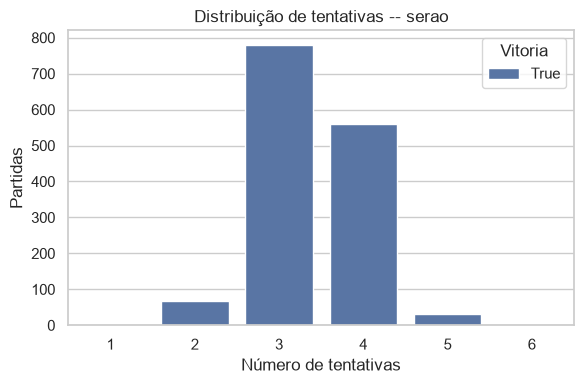


=== Análise exploratória -- Termo Solver ===
1. armar
2. cisao
3. pedir
4. serao

a. Analisar um dataset
c. Comparar vários datasets
r. Recarregar lista de datasets
s. Sair


,palavra_inicial,partidas,taxa_vitoria,tentativas_media,tentativas_mediana
0,cisao,1443,1.0,3.372834,3.0
1,serao,1443,1.0,3.387387,3.0
2,pedir,1443,1.0,3.433125,3.0
3,armar,1443,1.0,3.532918,4.0


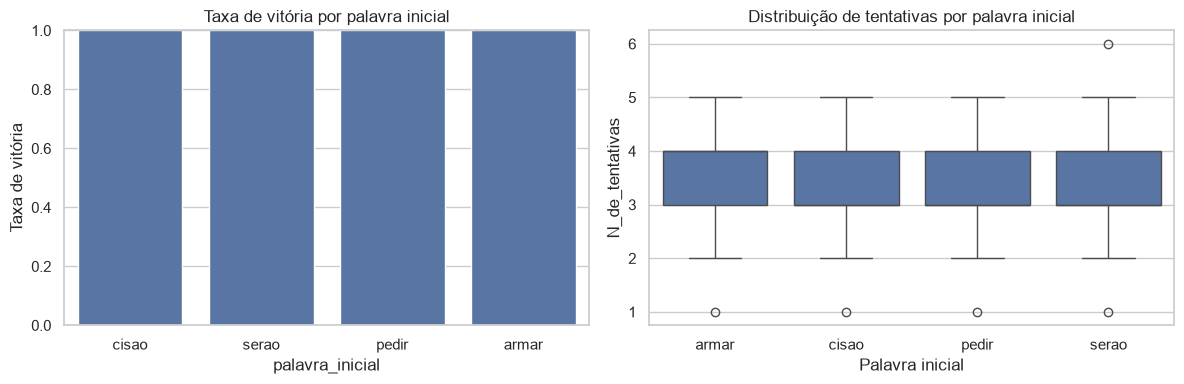


=== Análise exploratória -- Termo Solver ===
1. armar
2. cisao
3. pedir
4. serao

a. Analisar um dataset
c. Comparar vários datasets
r. Recarregar lista de datasets
s. Sair

=== Análise exploratória -- Termo Solver ===
1. armar
2. cisao
3. pedir
4. serao

a. Analisar um dataset
c. Comparar vários datasets
r. Recarregar lista de datasets
s. Sair
Até mais!


In [7]:
menu()